# **<p align="center"> Xi 1 Angle of Residues Analysis </p>**

## <ins> Description </ins>
### In this notebook we try to find the best way to extract ligand information out of unharmonic distributions

<details open>
<summary> <font size="6"> <ins>Key Points 2 </ins> </font> </summary>

- bulletpoint1

-  bulletpoint1

- [link]()

- image1: <img src="" width = 50%>

</details>

</br>

<details open>
<summary> <font size = "6"> <ins> Key Points 2 </ins> </font> </summary>

- `bulletpoint1`


- `bulletpoint2`



</details>

</br>


In [1]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator
# General Purpose Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
# Molecular Libraries
import gemmi 
# from rdkit import Chem
# import parasail
# Local Libraries
from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats,  get_res_CoM , get_atom_coord
from xaidar.data.molecModels import flatten_pdb, createPDB, clear_empty
from xaidar.data.molecModels import sele_pdb, sele_Lig, sele_AA, sele_chain_name

/home/eoo22534/mydir/xaidar/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Test python objs
test_pdb_path = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb")
test_pdb = loadPDB(test_pdb_path)
test_prot = sele_pdb( test_pdb, sele_AA)
test_prot_mon = sele_pdb( test_prot, sele_chain_name, chain_name = "A")
test_lig = sele_pdb( test_pdb, sele_Lig)
test_chain = flatten_pdb( test_prot_mon, "chain" )
test_res = test_chain[0][0] 
test_atom =  test_res[0]

---


In [7]:
angles_dir = rootdir.joinpath("data/ev2a/fragalysis/03-calcs/xi1anlges")
with open( angles_dir.joinpath("dihedral_angles_per_residue.pkl"), "rb") as f:
    lst_angles_per_res = pkl.load(f)

In [8]:
### Classify distribution modality

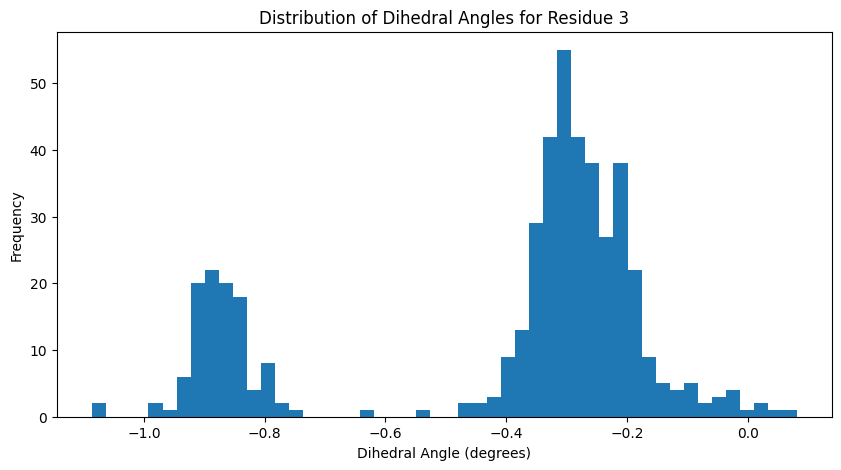

In [10]:
idx = 3
fig = plt.figure(figsize=(10,5))
plt.hist(lst_angles_per_res[idx], bins=50)
plt.xlabel("Dihedral Angle (degrees)")
plt.ylabel("Frequency")
plt.title("Distribution of Dihedral Angles for Residue {}".format(idx) )
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Assuming 'data' is your distribution (should be reshaped to (n_samples, 1))
# data = your_distribution.reshape(-1, 1)

data = np.array(lst_angles_per_res[idx])  # Example: using angles at residue 50

n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(data)
          for n in n_components]

# Calculate BIC and AIC
bic_values = [m.bic(data) for m in models]
aic_values = [m.aic(data) for m in models]

# Find the best k
best_k = n_components[np.argmin(bic_values)]
print(f"The optimal number of clusters is: {best_k}")

# Final model
best_gmm = models[np.argmin(bic_values)]

ValueError: Expected 2D array, got 1D array instead:
array=[-0.84811534 -0.94525873 -0.8866784  -0.81517825 -0.84379997 -0.90474746
 -0.87688625 -0.88653398 -0.81260438 -0.83048117 -0.83144129 -0.88207399
 -0.95657047 -0.98510077 -0.8394487  -0.90486091 -0.80117833 -0.87397332
 -0.91648263 -0.88887719 -0.89797352 -0.90143972 -0.8653883  -0.8731843
 -0.87926968 -0.92113371 -0.90160586 -0.77128227 -0.88457501 -0.89603011
 -1.08573315 -0.85231566 -0.86278647 -0.90992792 -0.86009754 -0.92402628
 -0.9404159  -0.8509842  -0.78538987 -0.88871099 -0.98422125 -0.8736848
 -0.86828661 -0.86264403 -0.34563591 -0.7715433  -0.29716503 -0.83181362
 -0.33087005 -0.85496461 -0.36057434 -0.819279   -0.2642373  -0.87631309
 -0.92649754 -0.8248671  -0.01678767 -0.86207216 -0.74395235 -0.86256231
 -0.18435566 -0.9130349  -0.91023326 -0.79935649 -0.27370877 -0.84762602
 -0.83688321 -0.90429559 -0.37198086 -0.91539922 -0.93056526 -0.87863226
 -0.87238298 -0.89486548 -0.85564053 -0.2767906  -0.89915527 -0.884

### How to compare dihedral angles

- Struggle: Within VS Between Modes

    - First, get a distribution of the angles

    - Get intermode distance, and within mode distance

        - How to compare the two?

- Struggle: One amino acid with multiple positions